In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import cftime
import cf_xarray
import warnings
warnings.filterwarnings("ignore")

In [2]:
import ecubevis as ecv

# Load Data

In [7]:
# #Open .nc file
# dsE = xr.open_dataset(r'/glade/work/mbadhan/LOCA2TrainingData/PrFinalDL4DS/PRCP_Livneh_Era5_25km_1940_2018.nc') #Livneh_Daily_Minimum_Temperature(1985-2014)
# # Select the time period from 1985 to 2014
# dsE_30Yr= dsE.sel(time=slice('1985-01-01', '2014-12-31'))

In [8]:
# #Create NetCDF file
# new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/Pr_Livneh_Era5_25km_1985_2014.nc'
# print ('saving to ', new_filename_1)
# dsE_30Yr.to_netcdf(path=new_filename_1)
# print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/Pr_Livneh_Era5_25km_1985_2014.nc
finished saving


In [28]:
ds_H = xr.open_dataset(r'/glade/work/mbadhan/GFDL_25km_Downscaled /Pr/Historical/Tar_Final_DS_25km.Pr_Product_gfdl.Historical_1985_2014.nc') #CMIP6_Historical(1985-2014)_25km_Downscaled_Using_ERA5
ds_S1 = xr.open_dataset(r'/glade/work/mbadhan/GFDL_25km_Downscaled /Pr/SSP585_SFDiff/Final_Product_w_wo_SF/Pr_TAR.DS25km.GFDL.SSP585_2070_2099W_SF.nc') #CMIP6_SSP585(2070-2099)_25km_Downscaled_Using_ERA5_SF_Adjusted(Diff)
dsE = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/Pr_Livneh_Era5_25km_1985_2014.nc') #Livneh_Daily_Precipitation(1985-2014)

In [10]:
ds_H

<xarray.Dataset>
Dimensions:                    (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                       (time) object 1985-01-01 12:00:00 ... 2014-12-...
  * lon                        (lon) float64 -78.5 -78.25 -78.0 ... -65.0 -64.75
  * lat                        (lat) float64 45.5 45.25 45.0 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr  (time, lat, lon) float32 ...

In [11]:
ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...

In [12]:
dsE

<xarray.Dataset>
Dimensions:   (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time      (time) datetime64[ns] 1985-01-01 1985-01-02 ... 2014-12-31
  * lon       (lon) float64 -78.5 -78.25 -78.0 -77.75 ... -65.25 -65.0 -64.75
  * lat       (lat) float64 45.5 45.25 45.0 44.75 44.5 ... 37.5 37.25 37.0 36.75
Data variables:
    PRCP      (time, lat, lon) float32 ...
    PRCP_fld  (time, lat, lon) float32 ...
Attributes:
    CDI:            Climate Data Interface version 2.3.0 (https://mpimet.mpg....
    Conventions:    CF-1.6
    missing_value:  -1e+36
    history:        Wed May 01 12:17:13 2024: cdo remapnn,25km_res_loca2.txt ...
    NCO:            4.7.2
    CDO:            Climate Data Operators version 2.3.0 (https://mpimet.mpg....

# Define Functions

In [15]:
def interpolation(df1,df2,target_val,start,end):
    #data1(df1) = cmip6 historic
    #data2(df2) = variable to be interpolated (ERA5)
    val = df2[start]+((target_val-df1[start])*(df2[end]-df2[start])/(df1[end]-df1[start]))
    

    return val

In [16]:
def manipulate(data_scaled, df, current_data_var, hist_data_var,cdf):
    
    interpolated_vals = []
    #cdf_val = []
    
    for i in range(len(data_scaled)):
        
        #find the index of closest value 
        start_ind = 0
        end_ind = 0
        
        index = np.abs(df[hist_data_var].values-data_scaled[i]).argmin()
        sign = (df[hist_data_var][index]-data_scaled[i])  #check 0,-  or + val
        
        
        
        try:
            if data_scaled[i] <= df[hist_data_var].max():

                if data_scaled[i] < df[hist_data_var].min():

                    start_ind = len(df)-1
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                    
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)

                #check the indices greater and smaller than the picked number
                elif sign == 0:      # ''df[hist_data_var][index]'' is basically a value at [hist_data_var]=column of a dataframe,[index]=row of a dataframe position
                    #no interpolation needed
                    interpolated_vals.append(df[current_data_var][index])
                            #cdf_val.append(df[cdf][index])


                elif sign > 0:    #Here, [hist_data_var]=column of a dataframe,[index]=row of a dataframe
                    
                    end_ind = index
                    start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)


                else:

                    start_ind = index
                    end_ind = len(df[df[hist_data_var] > df[hist_data_var][index]])-1
                 
    #                         #interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
                    interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                    interpolated_vals.append(interpolated_era5)
    #                         #cdf_val.append(interpolated_cdf)


            else:
                end_ind = 0
                start_ind = len(df) - len(df[df[hist_data_var] < df[hist_data_var][index]])
                
    #               interpolated_cdf = interpolation(df[hist_data_var],df[cdf],data_scaled[i],start_ind,end_ind)
    #               interpolated_era5 = interpolation(df[cdf],df[current_data_var],interpolated_cdf,start_ind,end_ind)
    #               interpolated_vals.append(interpolated_era5)
    #               cdf_val.append(interpolated_cdf)
                    #interpolated_vals.append(df[current_data_var].max())
                    #cdf_val.append(1)
                    #extrapolate
                interpolated_era5 = interpolation(df[hist_data_var],df[current_data_var],data_scaled[i],start_ind,end_ind)
                interpolated_vals.append(interpolated_era5) 
        
        except:
            print(i,": ", data_scaled[i], df[hist_data_var][index])
            
        #print(data_scaled[i], start_ind,",",end_ind)
            
    return interpolated_vals  #cdf_val

# Create Ordered Dataframe, Monthly Mean Ratio Calculations for Everygrid

In [17]:
#Create dataframe with ERA, CMIP6 and future data
#We will order the ERA and CMIP6, future data left as it is
#data1 = ERA netcdf
#data2 = CMIP6 netcdf
#future_data = SSP
def create_df_ordered(data1,data1_var,data2,data2_var,future_data, future_data_var,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era_grouped = data1.isel(time = data1.groupby("time.month").groups[month])[data1_var][:,lat_ind,lon_ind]
    hist_grouped = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind]
    future = future_data.isel(time = future_data.groupby("time.month").groups[month])[future_data_var][:,lat_ind,lon_ind].values
    
    #sort and unsort future data
    future_numpy = np.array(future)
    ind = np.flip(np.argsort(future_numpy))
    future_sorted = future_numpy[ind]
    
    
    grp_index = future_data.groupby("time.month").groups[month]
    
    era = era_grouped.sortby(era_grouped, ascending=False)
    hist = hist_grouped.sortby(hist_grouped, ascending=False)
    
    size = len(era)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        "ERA": era,
        "CMIP6": hist,
        "SSP" : future,
        "SSP_sorted": future_sorted,
        "cdf": cdf
    })

#     mean_cmip = df.CMIP6.mean()
#     mean_ssp = df.SSP.mean()
    from numpy import inf
    
    ratio = np.divide(df.SSP_sorted.values,df.CMIP6.values)
    ratio_corrected = np.nan_to_num(ratio,nan=0, posinf=0, neginf=0)
    
    #store ratio
    ratios = np.zeros(len(ratio_corrected))
    ratios[ind] = ratio_corrected
    
    df["ratio"] = ratios
    #values smaller than 0.0001 replaced by zero
    df.loc[df["SSP"] < 0.0002, ["SSP","ratio"]] = 0
    
    df["SSP_Scaled"] = df["SSP"]/df["ratio"]
    df["SSP_Scaled"].replace([np.inf,-np.inf,np.nan],0,inplace=True)
                             
    future_scaled = df["SSP_Scaled"].values
    
    
    #interpolation
    inter_data = manipulate(future_scaled,df,"ERA","CMIP6","cdf")
    

    scaled_data[grp_index,lat_ind,lon_ind] = future_scaled
    data[grp_index,lat_ind,lon_ind] = inter_data   #index for month(First Year Jan 0-30, then Second Year Jan 366-396,...)
    rat[grp_index,lat_ind,lon_ind] = df["ratio"].values
   
    return df

In [18]:
#numpy array for storing ratios
rat = np.zeros([10950,36,56])
data = np.zeros([10950,36,56])
scaled_data = np.zeros([10950,36,56])
for i in range(36):
    for j in range(56):
        for k in range(1,13):
            create_df_ordered(dsE,"PRCP_fld",ds_H,"Bias_corrected_DS_25km_Pr",ds_S1,"Bias_corrected_DS_25km_Pr_SFadj",i,j,k)
    print("processed: ",i)

processed:  0
processed:  1
processed:  2
processed:  3
processed:  4
processed:  5
processed:  6
processed:  7
processed:  8
processed:  9
processed:  10
processed:  11
processed:  12
processed:  13
processed:  14
processed:  15
processed:  16
processed:  17
processed:  18
processed:  19
processed:  20
processed:  21
processed:  22
processed:  23
processed:  24
processed:  25
processed:  26
processed:  27
processed:  28
processed:  29
processed:  30
processed:  31
processed:  32
processed:  33
processed:  34
processed:  35


In [29]:
ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...

In [30]:
ds_S1["Bias_corrected_pr"] = (['time', 'lat', 'lon'],  data) #save the file as netcdf

In [31]:
ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...
    Bias_corrected_pr                (time, lat, lon) float64 2.386 ... 1.138

In [32]:
ds_S1["Scaled_pr"] = (['time', 'lat', 'lon'], scaled_data)

In [33]:
ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...
    Bias_corrected_pr                (time, lat, lon) float64 2.386 ... 1.138
    Scaled_pr                        (time, lat, lon) float64 1.907 ... 1.154

In [34]:
ds_S1["ratio"] = (['time', 'lat', 'lon'], rat)

In [35]:
ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...
    Bias_corrected_pr                (time, lat, lon) float64 2.386 ... 1.138
    Scaled_pr                        (time, lat, lon) float64 1.907 ... 1.154
    ratio                            (time, lat, lon) float64 1.18 ... 0.6504

# Creating NetCDF

In [36]:
new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_25km_Bias_Corrected(0.0002)_2070_2099.nc'
print ('saving to ', new_filename_1)
ds_S1.to_netcdf(path=new_filename_1)
print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_25km_Bias_Corrected(0.0002)_2070_2099.nc
finished saving


In [37]:
corrected_ds_S1=xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_SSP585/Bias_Corrected/Pr_GFDL_SSP585_25km_Bias_Corrected(0.0002)_2070_2099.nc')

In [38]:
corrected_ds_S1

<xarray.Dataset>
Dimensions:                          (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                             (time) object 2070-01-01 12:00:00 ... 20...
  * lon                              (lon) float64 -78.5 -78.25 ... -65.0 -64.75
  * lat                              (lat) float64 45.5 45.25 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr_SFadj  (time, lat, lon) float64 ...
    Bias_corrected_pr                (time, lat, lon) float64 ...
    Scaled_pr                        (time, lat, lon) float64 ...
    ratio                            (time, lat, lon) float64 ...

# Test Subplot Plotting for 12 Months

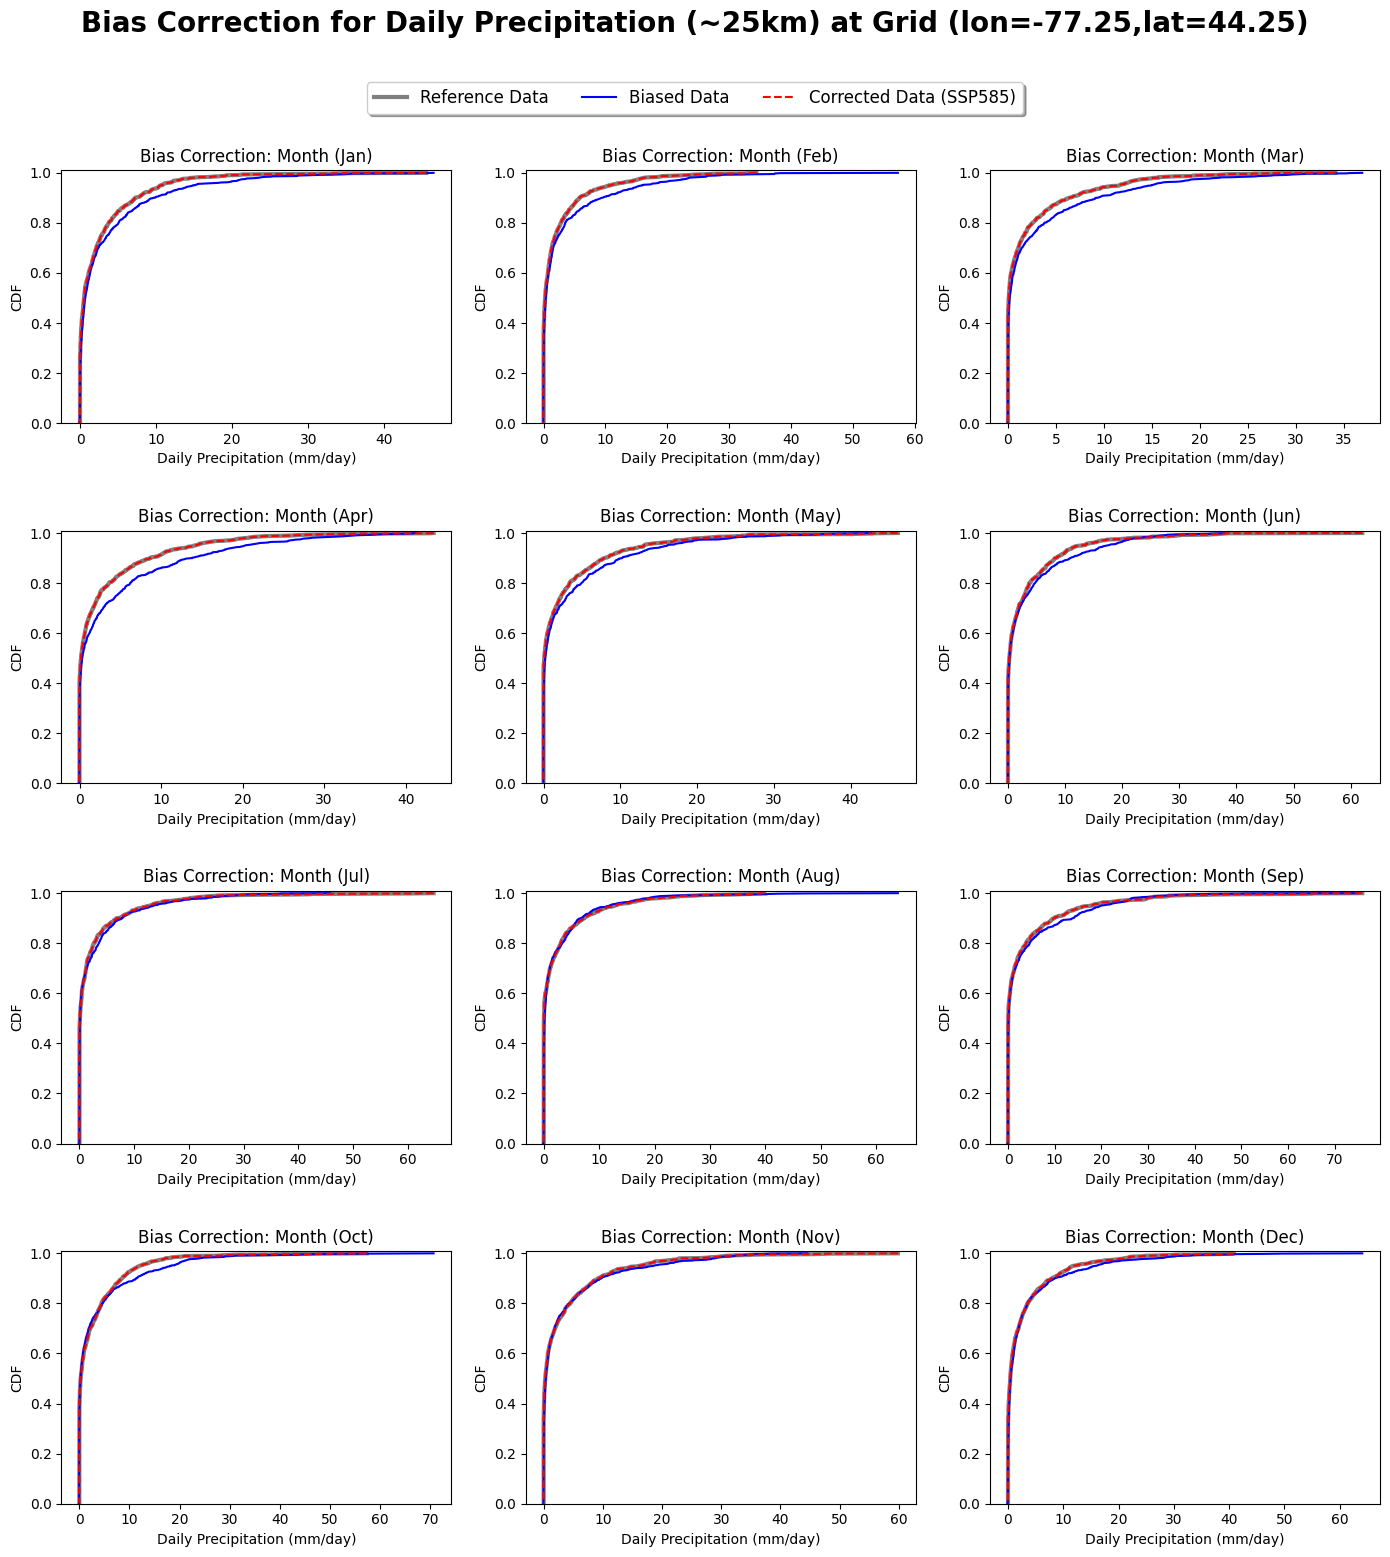

In [39]:
import matplotlib.pyplot as plt
import pandas as pd
import calendar


# Define your functions for creating dataframes here

def create_df(x_array, var, month, lat_ind, lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time

    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

def create_df_plot(data1, data1_var, data2, data2_var, data3, data3_var1, data3_var2, data3_var3, col1, col2, col3, col4, col5, col6, lat_ind, lon_ind, month):
    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = hist.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt4 = s1_Scaled.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt5 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

# Loop through each month and create subplots
fig, axs = plt.subplots(4, 3, figsize=(14, 16))

# Define a list of month names
month_names = [calendar.month_abbr[i] for i in range(1, 13)]  # Use month_abbr for abbreviated month names (e.g., Jan, Feb)

legend_handles = []  # List to collect legend handles
legend_labels = []   # List to collect legend labels

for month in range(1, 13):
    # Get the data for the current month
    dataset_plt = create_df_plot(dsE, "PRCP_fld", ds_H, "Bias_corrected_DS_25km_Pr", corrected_ds_S1, "Bias_corrected_DS_25km_Pr_SFadj", "Scaled_pr", "Bias_corrected_pr", "LIVNEH", "CMIP6_H", "SSP585_Original", "SSP585_Scaled", "Corrected_SSP585", "CDF", 5, 5, month)
    
    # Create the dataframe
    frame_plt = pd.DataFrame({
        "LIVNEH": dataset_plt.LIVNEH.values,
        "CMIP6_Hist": dataset_plt.CMIP6_H.values,
        "SSP_585_Original": dataset_plt.SSP585_Original.values,
        "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
        "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
        "CDF": dataset_plt.CDF.values
    })

    # Calculate subplot position
    row = (month - 1) // 3
    col = (month - 1) % 3
    
    # Plot on the current subplot
    ax = axs[row, col]
    ref_line,= ax.plot(frame_plt["LIVNEH"], frame_plt["CDF"], linewidth=3, color='gray', label="Reference Data")
    biased_line,= ax.plot(frame_plt["SSP_585_Original"], frame_plt["CDF"], color='blue', label="Biased Data")
    corrected_line,= ax.plot(frame_plt["SSP_585_Corrected"], frame_plt["CDF"], linestyle='--', color='red', label="Corrected Data (SSP585)")
    #ax.set_xlim(236, 305)  # x-axis limits
    ax.set_ylim(0, 1.01)   # y-axis limits
    ax.set_title(f"Bias Correction: Month ({month_names[month - 1]})")  # Use month
    ax.set_xlabel("Daily Precipitation (mm/day)")
    ax.set_ylabel("CDF")
    #ax.legend()

# Collect legend handles and labels
    if month == 1:  # Only collect legend handles and labels once
        legend_handles.append(ref_line)
        legend_handles.append(biased_line)
        legend_handles.append(corrected_line)
        legend_labels.append("Reference Data")
        legend_labels.append("Biased Data")
        legend_labels.append("Corrected Data (SSP585)")


# Add an overall title to the plot
plt.suptitle(f"Bias Correction for Daily Precipitation (~25km) at Grid (lon={dsE.lon.values[5]:.2f},lat={dsE.lat.values[5]:.2f})", fontsize=20, fontweight='bold',y=1.0)

# Add legend between subplot title and subplot
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), fontsize='large',fancybox=True, shadow=True, ncol=3)

# Adjust layout and display the plot with increased vertical spacing between subplots
plt.tight_layout(rect=[0, 0.03, 1, 0.95], h_pad=3.0)  # Adjust the layout to leave space for the shared title and legend

# # Specify the file path and save the plot
# file_path = r'/glade/work/mbadhan/Plot/Bias_Correction/Tmin_Diff_25km/Bias_Correction_Tmin_25km_w_livneh_2070_2099.png'

# plt.savefig(file_path, dpi=600)

plt.show()


# Plotting ( Here, all the steps are implemented before testing the subplot for 12 months)

In [20]:
def create_df(x_array,var,month,lat_ind,lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time
    
#    mean = data.mean().values
#    std  = data.std()
    
    #print("mean: ", mean,"standard dev: ",std)
    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

In [21]:
#create dataframe variables organized in descending order
def create_df_plot(data1,data1_var,data2,data2_var,data3,data3_var1,data3_var2,data3_var3,col1,col2,col3,col4,col5,col6,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    era = create_df(data1,data1_var,month,lat_ind,lon_ind)
    hist = create_df(data2,data2_var,month,lat_ind,lon_ind)
    s1 = create_df(data3,data3_var1,month,lat_ind,lon_ind)
    s1_Scaled = create_df(data3,data3_var2,month,lat_ind,lon_ind)
    s1_CR= create_df(data3,data3_var3,month,lat_ind,lon_ind)
    
    
    dt1 = era.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = hist.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt4 = s1_Scaled.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt5 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: dt4,
        col5: dt5,
        col6: cdf
    })
    
    return df

In [22]:
dataset_plt = create_df_plot(dsE,"Tmin_fld",ds_H,"Tmin_BC_downscaled_25km",corrected_ds_S1,"Tmin_25km_GFDL_DS", "Scaled_t2m", "Bias_corrected_t2m","LIVNEH","CMIP6_H","SSP585_Original","SSP585_Scaled","Corrected_SSP585","CDF",5,5,4)

In [23]:
dataset_plt.head(5)

,LIVNEH,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
0,290.580200,289.435577,293.544398,289.435577,290.580200,1.000000
1,288.957947,289.113617,293.539004,289.113617,288.957947,0.998889
2,288.453003,288.780334,292.138166,288.780334,288.453003,0.997778
3,288.010529,288.366028,291.787218,288.366028,288.010529,0.996667
4,287.819092,288.192841,291.445438,288.192841,287.819092,0.995556


In [24]:
dataset_plt.tail(5)

,LIVNEH,CMIP6_H,SSP585_Original,SSP585_Scaled,Corrected_SSP585,CDF
895,263.852783,264.891449,271.646539,264.891449,263.852783,0.005556
896,263.277039,263.484741,271.273673,263.484741,263.277039,0.004444
897,263.269745,262.892456,271.182449,262.892456,263.269745,0.003333
898,262.982208,262.606354,271.131812,262.606354,262.982208,0.002222
899,261.463593,261.748260,270.465833,261.748260,261.463593,0.001111


In [25]:
import xarray as xr 
# import the matplotlib, which is converted from matplot of MatLab
import matplotlib.pyplot as plt 
import pandas as pd
import glob
import math
import cartopy.crs as ccrs # Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
import numpy as np #package with multidimensional array manipulators
# the following section import individual functions from specific packages
from matplotlib import cm # import the cm function
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter #function to add lat/lon labels
from cartopy.util import add_cyclic_point #function to "wrap" the data into a sphere. Aka, the program adds values of 0° longitude next to 360° longitude, and 360° before 0 
from numpy import linspace # function to create evenly spaced numbers over a specified interval.

In [26]:
frame_plt = pd.DataFrame({
    "LIVNEH": dataset_plt.LIVNEH.values,
    "CMIP6_Hist":  dataset_plt.CMIP6_H.values,
    "SSP_585_Original": dataset_plt.SSP585_Original.values,
    "SSP_585_Scaled": dataset_plt.SSP585_Scaled.values,
    "SSP_585_Corrected": dataset_plt.Corrected_SSP585.values,
    "CDF": dataset_plt.CDF.values
})

In [27]:
frame_plt.head(30)

,LIVNEH,CMIP6_Hist,SSP_585_Original,SSP_585_Scaled,SSP_585_Corrected,CDF
0,290.580200,289.435577,293.544398,289.435577,290.580200,1.000000
1,288.957947,289.113617,293.539004,289.113617,288.957947,0.998889
2,288.453003,288.780334,292.138166,288.780334,288.453003,0.997778
3,288.010529,288.366028,291.787218,288.366028,288.010529,0.996667
4,287.819092,288.192841,291.445438,288.192841,287.819092,0.995556
5,287.576447,287.653442,291.397987,287.653442,287.576447,0.994444
6,287.552216,287.450928,291.140148,287.450928,287.552216,0.993333
7,287.214325,287.363678,291.120489,287.363678,287.214325,0.992222
8,287.167877,287.050598,290.781635,287.050598,287.167877,0.991111
9,286.899139,286.869720,290.731159,286.869720,286.899139,0.990000


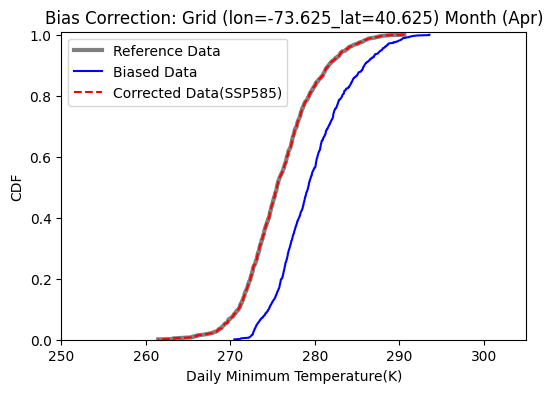

In [34]:
import matplotlib.pyplot as plt 
plt.figure(num=None, figsize=(6, 4),  facecolor='w', edgecolor='k')
        
ax = plt.gca()



check_indexed = frame_plt.set_index('CDF')
plt.plot(check_indexed["LIVNEH"],check_indexed.index, linewidth=3, color = 'gray',label="Reference Data")
plt.plot(check_indexed["SSP_585_Original"],check_indexed.index, color = 'blue',label="Biased Data")
#plt.plot(check_indexed["CMIP6_Hist"],check_indexed.index, color = 'pink',label="Historical Data")


#check_indexed = check.set_index('inter_cdf')
plt.plot(check_indexed["SSP_585_Corrected"],check_indexed.index,linestyle='--', color = 'red',label="Corrected Data(SSP585)")

plt.xlim(250, 305)  # x-axis limits
plt.ylim(0, 1.01)  # y-axis limits

plt.title("Bias Correction: Grid (lon=-73.625_lat=40.625) Month (Apr)")
plt.xlabel("Daily Minimum Temperature(K)")
plt.ylabel("CDF")
plt.legend()
plt.show()

# Task 2: Bias Correction of Historical Period simply using Quantile Mapping!

In [40]:
#Attention(Here ds_S1 is the Historical GFDL downscaled Data using DL4DS)
#load GFDL_25km Downscaled Data (ds_S1) using ERA5 as Training Data & Livneh Upscaled (25km) (dsL) as reference # We keep the reference time period same (1985-20014) for correcting bias
ds_S1 = xr.open_dataset(r'/glade/work/mbadhan/GFDL_25km_Downscaled /Pr/Historical/Tar_Final_DS_25km.Pr_Product_gfdl.Historical_1985_2014.nc') #CMIP6_Historical(1985-2014)_25km_Downscaled_Using_ERA5
dsL = xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/Pr_Livneh_Era5_25km_1985_2014.nc') #Livneh_Daily_Minimum_Temperature(1985-2014)

In [41]:
ds_S1

<xarray.Dataset>
Dimensions:                    (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                       (time) object 1985-01-01 12:00:00 ... 2014-12-...
  * lon                        (lon) float64 -78.5 -78.25 -78.0 ... -65.0 -64.75
  * lat                        (lat) float64 45.5 45.25 45.0 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr  (time, lat, lon) float32 ...

In [42]:
dsL 

<xarray.Dataset>
Dimensions:   (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time      (time) datetime64[ns] 1985-01-01 1985-01-02 ... 2014-12-31
  * lon       (lon) float64 -78.5 -78.25 -78.0 -77.75 ... -65.25 -65.0 -64.75
  * lat       (lat) float64 45.5 45.25 45.0 44.75 44.5 ... 37.5 37.25 37.0 36.75
Data variables:
    PRCP      (time, lat, lon) float32 ...
    PRCP_fld  (time, lat, lon) float32 ...
Attributes:
    CDI:            Climate Data Interface version 2.3.0 (https://mpimet.mpg....
    Conventions:    CF-1.6
    missing_value:  -1e+36
    history:        Wed May 01 12:17:13 2024: cdo remapnn,25km_res_loca2.txt ...
    NCO:            4.7.2
    CDO:            Climate Data Operators version 2.3.0 (https://mpimet.mpg....

In [43]:
def get_val(df):

    val = np.zeros(len(df.Livneh))
    for i in range(len(df.Livneh)):
        index = np.abs(df["GFDL_sorted"].values-df.loc[i,"GFDL"]).argmin()
        val[i] = df.Livneh[index]
        
    return val

# Create Ordered Dataframe, Monthly Mean Ratio Calculations for Everygrid

In [44]:
#create dataframe with Livneh Reference Data, downscaled CMIP6 25km (1985-2014)
#we will order the Livneh and CMIP6
#data1 = Livneh netcdf
#data2 = CMIP6 netcdf
def create_df_ordered_new(data1,data1_var,data2,data2_var,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    livneh_grouped = data1.isel(time = data1.groupby("time.month").groups[month])[data1_var][:,lat_ind,lon_ind]
    gfdl_grouped = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind]
    #gfdl = data2.isel(time = data2.groupby("time.month").groups[month])[data2_var][:,lat_ind,lon_ind].values
    
    #sort and unsort future data
    #gfdl_numpy = np.array(gfdl)
    #ind = np.flip(np.argsort(gfdl_numpy))
    #gfdl_sorted = gfdl_numpy[ind]
    
    
    grp_index = data2.groupby("time.month").groups[month]
    
    livneh_sorted = livneh_grouped.sortby(livneh_grouped, ascending=False)
    gfdl_sorted = gfdl_grouped.sortby(gfdl_grouped, ascending=False)
    
    size = len(livneh_sorted)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        "Livneh": livneh_sorted,
        "GFDL" : gfdl_grouped,
        "GFDL_sorted": gfdl_sorted,
        "cdf": cdf
    })

#     mean_cmip = df.CMIP6.mean()
#     mean_ssp = df.SSP.mean()

    #future_scaled = df["SSP_Scaled"].values
    
    #interpolation
    #inter_data = manipulate(future_scaled,df,"ERA","CMIP6","cdf")
    
    #get the corresponding row index
    data = get_val(df)

    final_data[grp_index,lat_ind,lon_ind] = data
    
    #data[grp_index,lat_ind,lon_ind] = inter_data   #index for month(First Year Jan 0-30, then Second Year Jan 366-396,...)
    #rat[grp_index,lat_ind,lon_ind] = df["ratio"].values
   
    return df

In [45]:
#numpy array for storing ratios
#rat = np.zeros([10950,10,15])
#data = np.zeros([10950,10,15])
final_data = np.zeros([10950,36,56])
for i in range(36):
    for j in range(56):
        for k in range(1,13):
            create_df_ordered_new(dsL,"PRCP_fld",ds_S1,"Bias_corrected_DS_25km_Pr",i,j,k)
    print("processed: ",i)

processed:  0
processed:  1
processed:  2
processed:  3
processed:  4
processed:  5
processed:  6
processed:  7
processed:  8
processed:  9
processed:  10
processed:  11
processed:  12
processed:  13
processed:  14
processed:  15
processed:  16
processed:  17
processed:  18
processed:  19
processed:  20
processed:  21
processed:  22
processed:  23
processed:  24
processed:  25
processed:  26
processed:  27
processed:  28
processed:  29
processed:  30
processed:  31
processed:  32
processed:  33
processed:  34
processed:  35


In [ ]:
# Ran following five cells just to check it the above algorithm went well 

In [52]:
test_liv = dsL.isel(time = dsL.groupby("time.month").groups[1])["PRCP_fld"][:,0,0].values
test_s1 = ds_S1.isel(time = ds_S1.groupby("time.month").groups[1])["Bias_corrected_DS_25km_Pr"][:,0,0].values

In [53]:
tL = -np.sort(-test_liv)     #'tL' is the sorted livneh data
tS1 = -np.sort(-test_s1)     # 'tS1' is the sorted GFDL data

In [54]:
test_df = pd.DataFrame({
    "tL" : tL,
    "ts" : tS1,
    "data" : test_s1                    #test_s1 is the unsorted GFDL data
})

In [59]:
test_df.head(84)

,tL,ts,data
0,26.293028,34.615429,0.519672
1,23.418301,30.839443,7.110728
2,21.247236,27.079645,0.027435
3,20.466341,26.281969,5.045163
4,20.208900,25.412939,5.456322
...,...,...,...
79,8.135048,7.110728,0.201447
80,8.126467,7.103949,3.382983
81,8.109304,6.982999,0.212463
82,8.032073,6.841461,0.049916


In [60]:
final_data[:5,0,0]

array([0.6350143 , 8.13504791, 0.        , 6.26433039, 6.94225121])

In [46]:
ds_S1["Bias_corrected_pr"] = (['time', 'lat', 'lon'],  final_data) #save the file as netcdf

# Creating NetCDF

In [47]:
new_filename_1 = r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_25km_Bias_Corrected_1985_2014.nc'
print ('saving to ', new_filename_1)
ds_S1.to_netcdf(path=new_filename_1)
print ('finished saving')

saving to  /glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_25km_Bias_Corrected_1985_2014.nc
finished saving


In [62]:
corrected_ds_S1=xr.open_dataset(r'/glade/work/mbadhan/Bias_Correction_25kmGFDL_using_Livneh_1985_2014/PRCP/GFDL_Historical/Bias_Corrected/Pr_GFDL.Historical_25km_Bias_Corrected_1985_2014.nc')

In [63]:
corrected_ds_S1

<xarray.Dataset>
Dimensions:                    (time: 10950, lon: 56, lat: 36)
Coordinates:
  * time                       (time) object 1985-01-01 12:00:00 ... 2014-12-...
  * lon                        (lon) float64 -78.5 -78.25 -78.0 ... -65.0 -64.75
  * lat                        (lat) float64 45.5 45.25 45.0 ... 37.0 36.75
Data variables:
    Bias_corrected_DS_25km_Pr  (time, lat, lon) float32 ...
    Bias_corrected_pr          (time, lat, lon) float64 ...

# Plotting

In [64]:
def create_df(x_array,var,month,lat_ind,lon_ind):
    groups = x_array.groupby("time.month").groups
    filtered = x_array.isel(time=groups[month])
    data = filtered[var][:,lat_ind,lon_ind]
    time = filtered.time
    
#    mean = data.mean().values
#    std  = data.std()
    
    #print("mean: ", mean,"standard dev: ",std)
    
    df = pd.DataFrame({
        "Date": time,
        "Min_Temp" : data})
    
    return df

In [65]:
#create dataframe variables organized in descending order
def create_df_plot(data1,data1_var,data2,data2_var1,data2_var2,col1,col2,col3,col4,lat_ind,lon_ind,month):
    
    #create_df(x_array,var,month,lat_ind,lon_ind):

    livneh = create_df(data1,data1_var,month,lat_ind,lon_ind)
    s1 = create_df(data2,data2_var1,month,lat_ind,lon_ind)
    s1_CR= create_df(data2,data2_var2,month,lat_ind,lon_ind)
    
    
    dt1 = livneh.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt2 = s1.sort_values("Min_Temp", ascending = False).Min_Temp.values
    dt3 = s1_CR.sort_values("Min_Temp", ascending = False).Min_Temp.values
    
    size = len(dt1)
    cdf = [i/size for i in range(size,0,-1)]
    
    df = pd.DataFrame({
        col1: dt1,
        col2: dt2,
        col3: dt3,
        col4: cdf
    })
    
    return df

In [66]:
dataset_plt = create_df_plot(dsL,"PRCP_fld",corrected_ds_S1,"Bias_corrected_DS_25km_Pr", "Bias_corrected_pr", "LIVNEH","Historical_GFDL25km","Corrected_Historical25km","CDF",5,5,4)

In [67]:
import xarray as xr 
# import the matplotlib, which is converted from matplot of MatLab
import matplotlib.pyplot as plt 
import pandas as pd
import glob
import math
import cartopy.crs as ccrs # Python package designed for geospatial data processing in order to produce maps and other geospatial data analyses.
import numpy as np #package with multidimensional array manipulators
# the following section import individual functions from specific packages
from matplotlib import cm # import the cm function
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter #function to add lat/lon labels
from cartopy.util import add_cyclic_point #function to "wrap" the data into a sphere. Aka, the program adds values of 0° longitude next to 360° longitude, and 360° before 0 
from numpy import linspace # function to create evenly spaced numbers over a specified interval.

In [68]:
dataset_plt 

,LIVNEH,Historical_GFDL25km,Corrected_Historical25km,CDF
0,43.420700,36.818428,43.420700,1.000000
1,43.039116,36.648571,43.039116,0.998889
2,34.865101,33.016239,34.865101,0.997778
3,33.017410,31.764923,33.017410,0.996667
4,30.647545,31.528503,30.647545,0.995556
...,...,...,...,...
895,0.000000,-0.009313,0.000000,0.005556
896,0.000000,-0.009340,0.000000,0.004444
897,0.000000,-0.011847,0.000000,0.003333
898,0.000000,-0.019891,0.000000,0.002222


In [69]:
frame_plt = pd.DataFrame({
    "LIVNEH": dataset_plt.LIVNEH.values,
    "Historical_Original_25km": dataset_plt.Historical_GFDL25km.values,
    "Bias-Corrected_Historical_25km": dataset_plt.Corrected_Historical25km.values,
    "CDF": dataset_plt.CDF.values
})

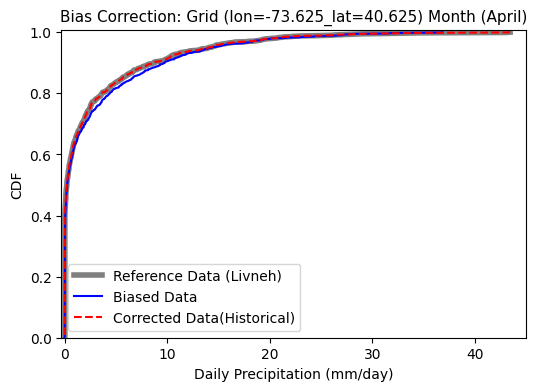

In [80]:
import matplotlib.pyplot as plt 
plt.figure(num=None, figsize=(6, 4),  facecolor='w', edgecolor='k')
        
ax = plt.gca()



check_indexed = frame_plt.set_index('CDF')
plt.plot(check_indexed["LIVNEH"],check_indexed.index, linewidth=4, color = 'gray',label="Reference Data (Livneh)")
plt.plot(check_indexed["Historical_Original_25km"],check_indexed.index, color = 'blue',label="Biased Data")
#plt.plot(check_indexed["CMIP6_Hist"],check_indexed.index, color = 'pink',label="Historical Data")


#check_indexed = check.set_index('inter_cdf')
plt.plot(check_indexed["Bias-Corrected_Historical_25km"],check_indexed.index,linestyle='--', color = 'red',label="Corrected Data(Historical)")

plt.xlim(-.35, 45)  # x-axis limits
plt.ylim(0, 1.008)  # y-axis limits

plt.title("Bias Correction: Grid (lon=-73.625_lat=40.625) Month (April)",fontsize=11, loc="center")
plt.xlabel("Daily Precipitation (mm/day)")
plt.ylabel("CDF")
plt.legend()

# Specify the file path and save the plot
#file_path = r'/glade/work/mbadhan/Plot/Bias_Correction/Tmin/Bias_Correction_Tmin_25km_w_livneh_Apr_2070_2099_UpD.png'

#plt.savefig(file_path, dpi=600)

plt.show()